In [1]:
# =============================================================================
# Angers urban drainage network (UDN) -- preprocessing
# -----------------------------------------------------------------------------
# Builds the two canonical tables consumed by the reconstruction notebooks:
#   df_pipe : pipe_id, material, diameter
#   df_node : node_id, x, y, rimElevation, invertElevation
# from the raw wastewater/stormwater CSV exports.
# =============================================================================
import pandas as pd
import numpy as np
from pyproj import Transformer
import function
import importlib

importlib.reload(function)

from function import *

In [2]:
# ── Pipe table ───────────────────────────────────────────────────────────
# Load the wastewater and stormwater pipe exports, keep only the three
# attributes needed downstream, rename to the canonical schema, and
# concatenate both networks into a single pipe table.
df_waste = pd.read_csv("../data/Angers/Wastewater/Angers_Wastewater_Pipes.csv", sep=";")
df_storm = pd.read_csv("../data/Angers/Stormwater/Angers_Stormwater_Pipes.csv", sep=";")

df_waste = df_waste[["NUMERO", "MATERIAU", "DIAMETRE"]]
df_storm = df_storm[["NUMERO", "MATERIAU", "DIAMETRE"]]

df_waste = df_waste.rename(columns={"NUMERO": "pipe_id", "MATERIAU": "material", "DIAMETRE": "diameter"})
df_storm = df_storm.rename(columns={"NUMERO": "pipe_id", "MATERIAU": "material", "DIAMETRE": "diameter"})

df_pipe = pd.concat([df_waste, df_storm]).reset_index(drop = True)

In [3]:
# Exactly one pipe is missing its id in the raw export; its id
# (206414525) is created by cross-checking the raw source data, and is
# confirmed not already in use elsewhere (which would create a collision).
print(df_pipe[df_pipe["pipe_id"].isna()])
print()
print("Already used ? ",df_pipe[df_pipe["pipe_id"] == 206414525])

df_pipe.loc[97247, "pipe_id"] = 206414525

       pipe_id material  diameter
97247      NaN       NC     400.0

Already used ?  Empty DataFrame
Columns: [pipe_id, material, diameter]
Index: []


In [4]:
# Cast pipe_id to a plain integer dtype now that no NaN remains.
df_pipe["pipe_id"] = df_pipe["pipe_id"].astype(int)

In [5]:
# Sanity check: no duplicate pipe ids should remain after the fix above.
df_pipe[df_pipe["pipe_id"].duplicated()]

,pipe_id,material,diameter


In [6]:
# Diameter distribution, used to calibrate the upper bound applied below
print(df_pipe["diameter"].describe())
print("99 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.99))
print("99,9 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.999))

count     96997.000000
mean        274.648432
std         801.819045
min           0.000000
25%         160.000000
50%         200.000000
75%         315.000000
max      130080.000000
Name: diameter, dtype: float64
99 percentile = 1000.0
99,9 percentile = 1800.0


In [7]:
# The recorded maximum (130,080 mm) is almost certainly a data-entry error;
# diameters at or below 0 or at/above 5000 mm are treated as physically
# implausible for this network and set to NaN (the pipe itself is kept --
# only its diameter value is discarded, to be reconstructed later).
mask = (df_pipe["diameter"] <= 0.0) | (df_pipe["diameter"] >= 5000)
df_pipe.loc[mask, "diameter"] = np.nan

material
PVC                32582
NC                 26790
BETON              20079
AC                 14523
PP                   923
BA                   650
F                    632
PEHD                 355
GRES                 227
PRV                   56
AC_REHAB              31
BETON_ANNELE          30
PVC_ANNELE            17
PE_ANNELE             14
PIERRE NAT            13
MACONNE               12
ACIER                 12
Béton armé            11
PVC_HTE_DENSITE       10
PVC315                 8
Béton                  5
Fonte                  3
AC150                  3
MC                     3
BETON_REHAB            2
FD REVETU              1
BAM                    1
PVC_PRESSION           1
FONTE                  1
Beton armé             1
FONTE BETON            1
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

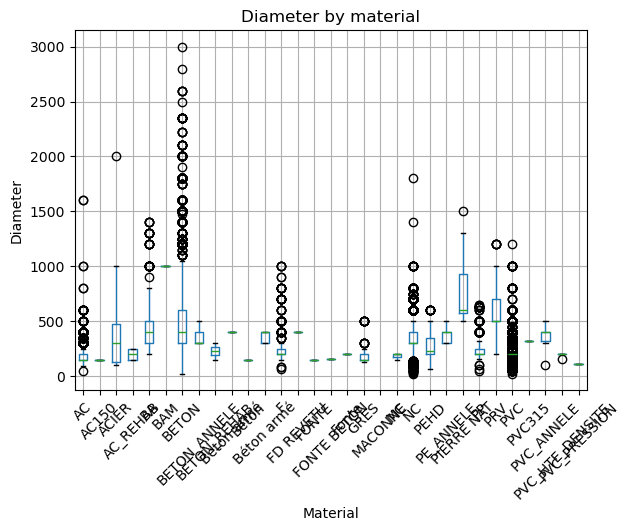

material
Plastic            33910
Undetermined       27046
Concrete           21030
Asbestos-cement    14557
Metal                649
Glass                 56
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

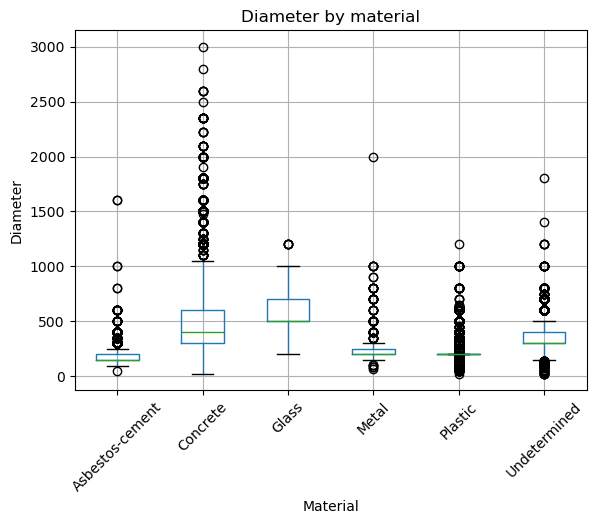

In [8]:
# ── Material category grouping (manuscript Section 2.2.4) ─────────────────
def map_material(mat):
    if mat in plastic:
        return "Plastic"
    elif mat in concrete:
        return "Concrete"
    elif mat in metal:
        return "Metal"
    elif mat in asbestos_cement:
        return "Asbestos-cement"
    elif mat in glass:
        return "Glass"
    else:
        return "Undetermined"

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

plastic = ["PVC", "PP", "PEHD", "PE_ANNELE", "PVC_ANNELE", "PVC_HTE_DENSITE", "PVC315", "PVC_PRESSION"]
concrete = ["BETON", "BA", "GRES", "BETON_ANNELE", "PIERRE NAT", "MACONNE", "Béton armé", "Béton", "BETON_REHAB", "Beton armé"]
metal = ["F", "ACIER", "Fonte", "Acier", "Inox", "FD REVETU", "FONTE"]
asbestos_cement = ["AC", "AC_REHAB", "AC150"]
glass = ["PRV"]

df_pipe["material"] = df_pipe["material"].apply(map_material)

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

In [7]:
# ── Node table ───────────────────────────────────────────────────────────
# Load the wastewater and stormwater manhole exports. Coordinates are split
# out of the combined "Geo Point" field before the columns are subset to
# the ones needed downstream.
df_waste = pd.read_csv("../data/Angers/Wastewater/Angers_Wastewater_Manholes.csv", sep=";")
df_storm = pd.read_csv("../data/Angers/Stormwater/Angers_Stormwater_Manholes.csv", sep=";")

df_waste[["x", "y"]] = df_waste["Geo Point"].str.split(", ", expand = True).astype("float")
df_storm[["x", "y"]] = df_storm["Geo Point"].str.split(", ", expand = True).astype("float")


df_waste = df_waste[["GID", "x", "y", "RADIER", "ZSURF"]]
df_storm = df_storm[["NUMERO", "x", "y", "Z_FE_ENTREE1", "ZSURF"]]

df_storm = df_storm.rename(columns={"NUMERO": "node_id", "Z_FE_ENTREE1": "invertElevation", "ZSURF": "rimElevation"})
df_waste = df_waste.rename(columns={"GID": "node_id", "RADIER": "invertElevation", "ZSURF": "rimElevation"})

df_node = pd.concat([df_waste, df_storm]).reset_index(drop = True)

In [8]:
# Reproject from the source CRS (EPSG:4326) to the network's working CRS
# (EPSG:2154, Lambert-93).
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
df_node["x"], df_node["y"] = transformer.transform(df_node["y"].values, df_node["x"].values)

In [9]:
# One colliding pair of duplicate node ids is expected; it is relabelled by
# row position below. 
print(df_node[df_node[["node_id"]].duplicated(keep = False)])

df_node.loc[84370, "node_id"] = 18968

       node_id              x             y  invertElevation  rimElevation
27022    18967  433596.129518  6.713277e+06            38.97         40.57
84370    18967  432943.327515  6.714224e+06            25.21         27.23


In [10]:
# Distinct nodes sharing the exact same coordinates are collapsed, keeping
# the first occurrence. Unlike the node_id collision above, the number of
# coincident-location duplicates is not a fixed, asserted expectation.
print("Coincident-location duplicate rows:", df_node[["x", "y"]].duplicated(keep=False).sum())
df_node = df_node.drop_duplicates(subset=["x","y"], keep="first")

Coincident-location duplicate rows: 288


In [13]:
# ── Removal of physically impossible node-level values (Section 2.2.2) ────
# Elevations outside the admissible range for this network are discarded,
# and invert elevations exceeding the rim elevation at the same node are
# set to NaN as a hydraulically impossible configuration.
columns = [
    "invertElevation",
    "rimElevation",
]

nan_before = df_node[columns].isna().sum()

df_node["invertElevation"] = discardHeightImpossible(df_node, "invertElevation", 0, 200)
df_node["rimElevation"] = discardHeightImpossible(df_node, "rimElevation", 0, 200)

mask = df_node["invertElevation"] > df_node["rimElevation"]
df_node.loc[mask, "invertElevation"] = np.nan
df_node.loc[mask, "rimElevation"] = np.nan

nan_after = df_node[columns].isna().sum()

nan_diff = pd.DataFrame({
    "NaN_before": nan_before,
    "NaN_after": nan_after,
    "increase": nan_after - nan_before,
    "increase_%": ((nan_after - nan_before) / len(df_node) * 100).round(2)
})

print(nan_diff)

                 NaN_before  NaN_after  increase  increase_%
invertElevation        5395      25006     19611       23.28
rimElevation           5276      22234     16958       20.13


In [14]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the cleaned pipe and node tables to disk (pickle format) for the
# downstream reconstruction notebooks.
df_pipe.to_pickle("../data/Angers/df_pipe_Angers.pkl")
df_node.to_pickle("../data/Angers/df_node_Angers.pkl")